In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Stats
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.dpi'] = 130
print("Ready ✓")

Ready ✓


In [2]:
btc = pd.read_csv('../data/btc_clean.csv', index_col='date', parse_dates=True)
series = btc['close'].copy()

print(f"Total rows: {len(series)}")
series.tail()

Total rows: 1006


date
2024-12-26    95795.515625
2024-12-27    94164.859375
2024-12-28    95163.929688
2024-12-29    93530.226562
2024-12-30    92643.210938
Name: close, dtype: float64

In [3]:
def adf_test(series, name="Series"):
    result = adfuller(series.dropna())
    print(f"\n{'='*40}")
    print(f"ADF Test — {name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Critical (5%) : {result[4]['5%']:.4f}")
    
    if result[1] < 0.05:
        print("  ✅ STATIONARY — ready for ARIMA")
    else:
        print("  ❌ NON-STATIONARY — need differencing")

adf_test(series, "BTC Close Price")


ADF Test — BTC Close Price
  ADF Statistic : 0.6736
  p-value       : 0.9893
  Critical (5%) : -2.8645
  ❌ NON-STATIONARY — need differencing



ADF Test — BTC Close Price (1st Difference)
  ADF Statistic : -7.3121
  p-value       : 0.0000
  Critical (5%) : -2.8645
  ✅ STATIONARY — ready for ARIMA


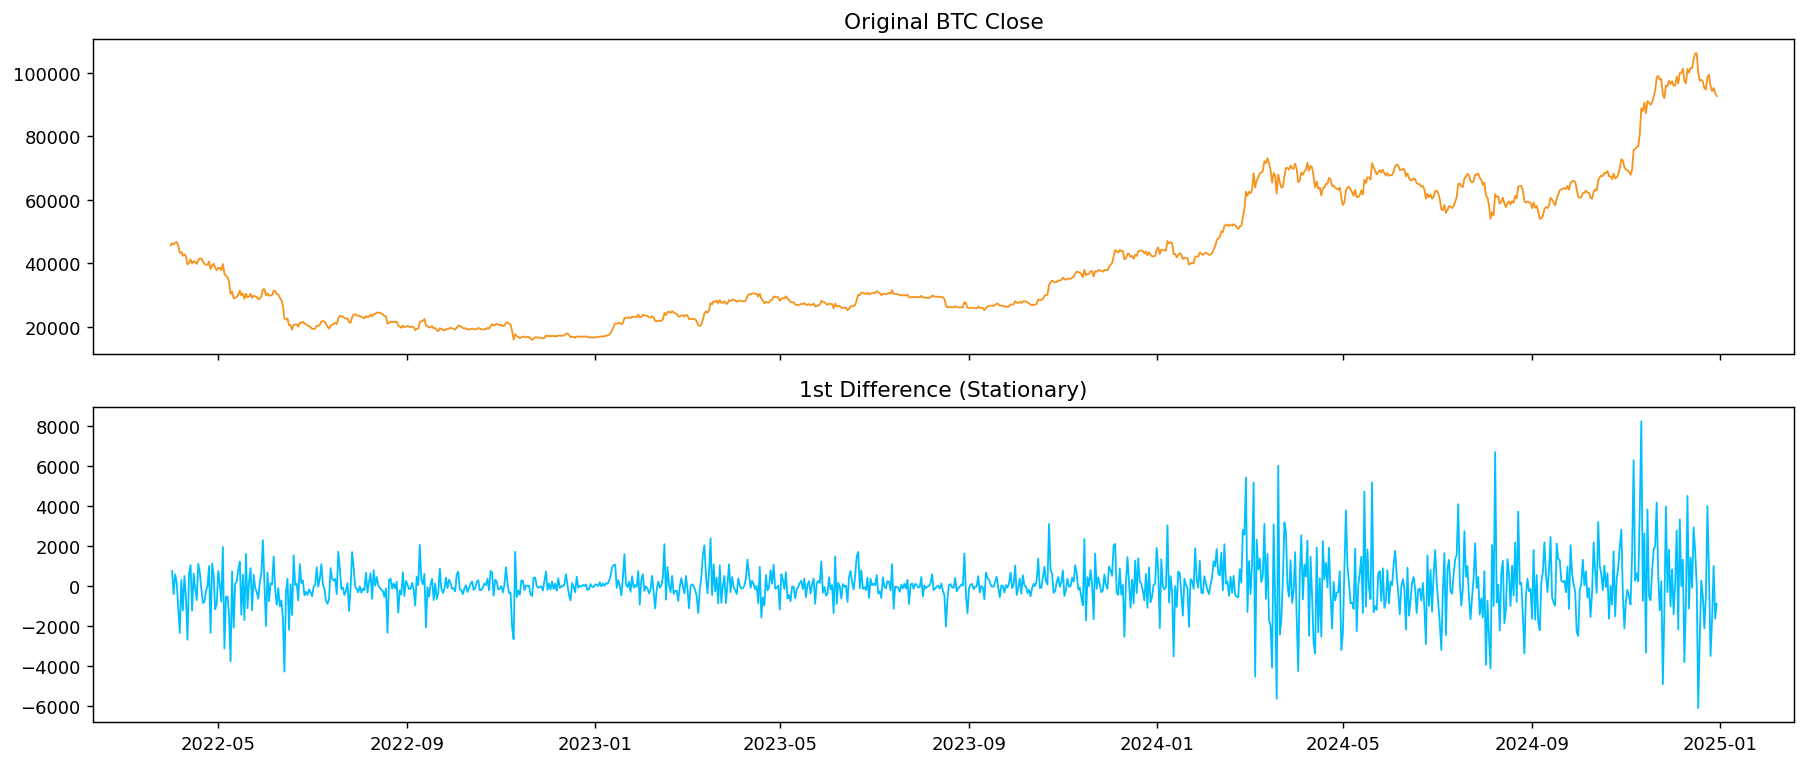

In [4]:
series_diff = series.diff().dropna()
adf_test(series_diff, "BTC Close Price (1st Difference)")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(series,      color='#F7931A', linewidth=1); axes[0].set_title('Original BTC Close')
axes[1].plot(series_diff, color='#00BFFF', linewidth=1); axes[1].set_title('1st Difference (Stationary)')
plt.tight_layout()
plt.show()

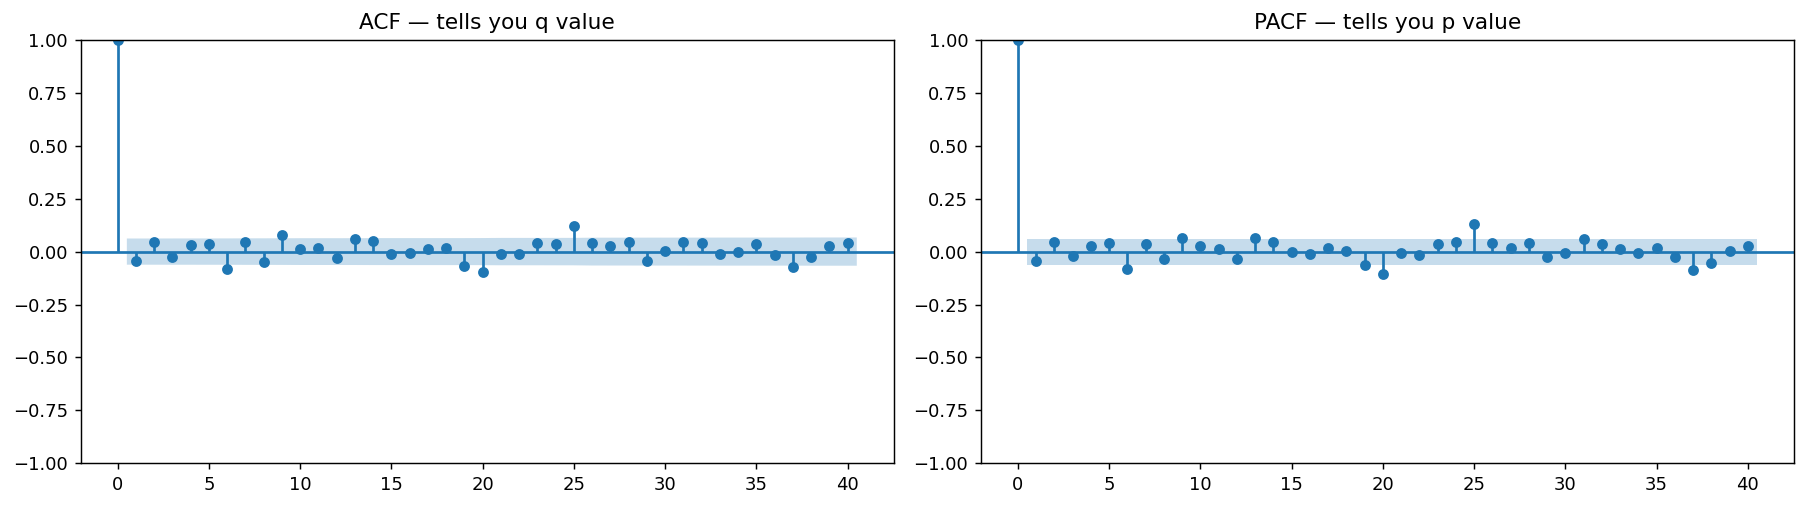

Read the plots → first bar outside blue band = your p/q


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_diff,  lags=40, ax=axes[0], title='ACF — tells you q value')
plot_pacf(series_diff, lags=40, ax=axes[1], title='PACF — tells you p value')
plt.tight_layout()
plt.show()

# Reading the plots:
# p = lags before PACF cuts off → typically 1-3
# d = 1 (we differenced once)
# q = lags before ACF cuts off  → typically 1-3
print("Read the plots → first bar outside blue band = your p/q")

In [6]:
# Use last 60 days as test set
train_size = len(series) - 60
train = series.iloc[:train_size]
test  = series.iloc[train_size:]

print(f"Train: {len(train)} days | Test: {len(test)} days")

# Fit ARIMA(p=2, d=1, q=2) — adjust p/q based on your ACF/PACF plots
model = ARIMA(train, order=(2, 1, 2))
fitted = model.fit()
print(fitted.summary())

Train: 946 days | Test: 60 days


C:\Users\hisid\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\hisid\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\hisid\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                  946
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -7989.537
Date:                Sun, 29 Mar 2026   AIC                          15989.075
Time:                        03:50:12   BIC                          16013.330
Sample:                    03-31-2022   HQIC                         15998.319
                         - 10-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6209      0.328      1.892      0.058      -0.022       1.264
ar.L2         -0.3423      0.322     -1.063      0.288      -0.974       0.289
ma.L1         -0.6554      0.325     -2.018      0.0


ARIMA Results:
  MAE  : $22,489.16
  RMSE : $24,295.43
  MAPE : 23.41%


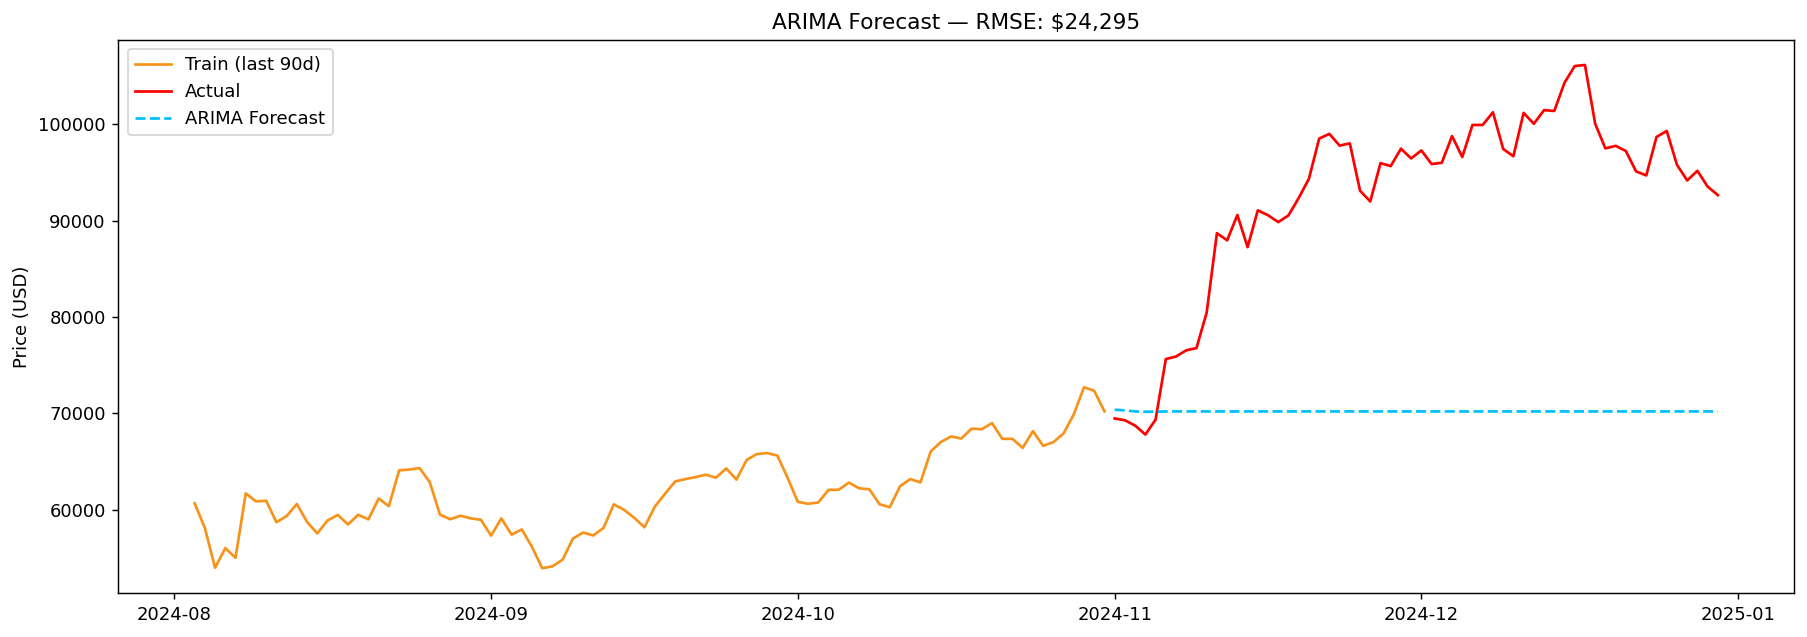

In [8]:
# Forecast 60 steps ahead
forecast_result = fitted.forecast(steps=60)
forecast = pd.Series(forecast_result.values, index=test.index)

# Metrics
mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print(f"\nARIMA Results:")
print(f"  MAE  : ${mae:,.2f}")
print(f"  RMSE : ${rmse:,.2f}")
print(f"  MAPE : {mape:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-90:], train[-90:], color='#F7931A', label='Train (last 90d)')
ax.plot(test.index,        test,        color='red',   label='Actual', linewidth=1.5)
ax.plot(forecast.index,    forecast,    color='#00BFFF', label='ARIMA Forecast',
        linewidth=1.5, linestyle='--')
ax.set_title(f'ARIMA Forecast — RMSE: ${rmse:,.0f}')
ax.legend(); ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.savefig('../data/arima_forecast.png', dpi=150)
plt.show()

In [9]:
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

df_prophet = btc[['close']].reset_index()
df_prophet.columns = ['ds', 'y']

# Remove timezone if present
df_prophet['ds'] = pd.to_datetime(df_prophet['ds']).dt.tz_localize(None)

print(df_prophet.head())
print(f"Shape: {df_prophet.shape}")

          ds             y
0 2022-03-31  45538.675781
1 2022-04-01  46281.644531
2 2022-04-02  45868.949219
3 2022-04-03  46453.566406
4 2022-04-04  46622.675781
Shape: (1006, 2)


In [10]:
train_prophet = df_prophet.iloc[:-60]
test_prophet  = df_prophet.iloc[-60:]

print(f"Train: {len(train_prophet)} | Test: {len(test_prophet)}")

Train: 946 | Test: 60


In [11]:
model_prophet = Prophet(
    changepoint_prior_scale=0.05,   # flexibility of trend (higher = more flexible)
    seasonality_mode='multiplicative',  # crypto grows multiplicatively
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model_prophet.fit(train_prophet)
print("Prophet model trained ✓")

03:53:32 - cmdstanpy - INFO - Chain [1] start processing
03:53:34 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained ✓


In [12]:
# Create future dates — 60 days ahead
future = model_prophet.make_future_dataframe(periods=60)
forecast_prophet = model_prophet.predict(future)

# Extract what we need
forecast_prophet_test = forecast_prophet[['ds','yhat','yhat_lower','yhat_upper']].tail(60)
forecast_prophet_test = forecast_prophet_test.set_index('ds')

print(forecast_prophet_test.head())

                    yhat    yhat_lower    yhat_upper
ds                                                  
2024-11-01  72147.718971  69315.361950  74842.262722
2024-11-02  72429.864521  69538.972137  75223.401554
2024-11-03  72745.119650  69894.720244  75542.674218
2024-11-04  73316.711645  70374.005902  76391.001613
2024-11-05  73068.916103  70116.760189  76099.823597



Prophet Results:
  MAE  : $16,044.31
  RMSE : $17,267.28
  MAPE : 16.82%


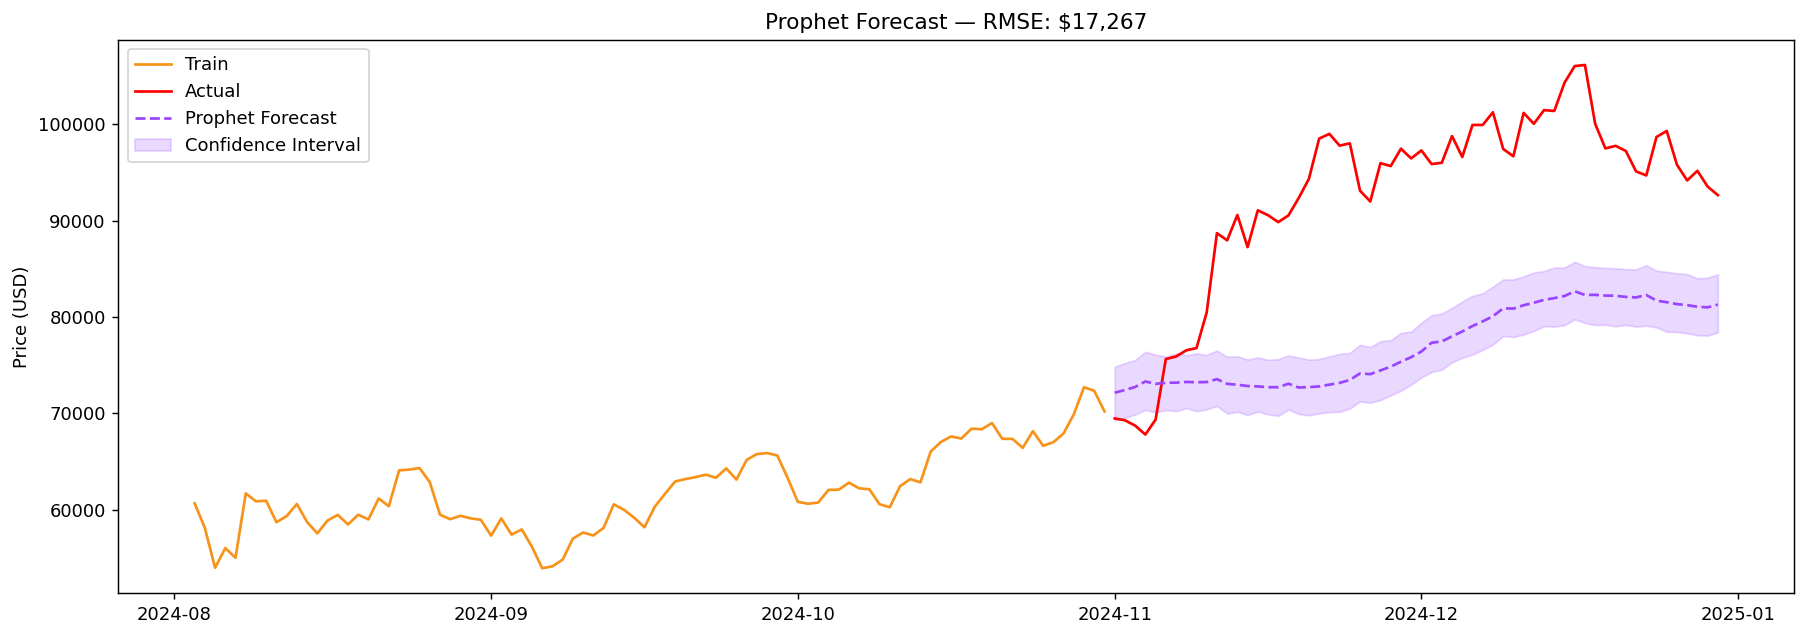

In [14]:
actual = test_prophet.set_index('ds')['y']
predicted = forecast_prophet_test['yhat']

mae_p  = mean_absolute_error(actual, predicted)
rmse_p = np.sqrt(mean_squared_error(actual, predicted))
mape_p = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"\nProphet Results:")
print(f"  MAE  : ${mae_p:,.2f}")
print(f"  RMSE : ${rmse_p:,.2f}")
print(f"  MAPE : {mape_p:.2f}%")

# Plot with confidence interval
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_prophet['ds'].tail(90), train_prophet['y'].tail(90),
        color='#F7931A', label='Train')
ax.plot(actual.index, actual.values,
        color='red', linewidth=1.5, label='Actual')
ax.plot(predicted.index, predicted.values,
        color='#9945FF', linewidth=1.5, linestyle='--', label='Prophet Forecast')
ax.fill_between(forecast_prophet_test.index,
                forecast_prophet_test['yhat_lower'],
                forecast_prophet_test['yhat_upper'],
                alpha=0.2, color='#9945FF', label='Confidence Interval')
ax.set_title(f'Prophet Forecast — RMSE: ${rmse_p:,.0f}')
ax.legend(); ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.savefig('../data/prophet_forecast.png', dpi=150)
plt.show()

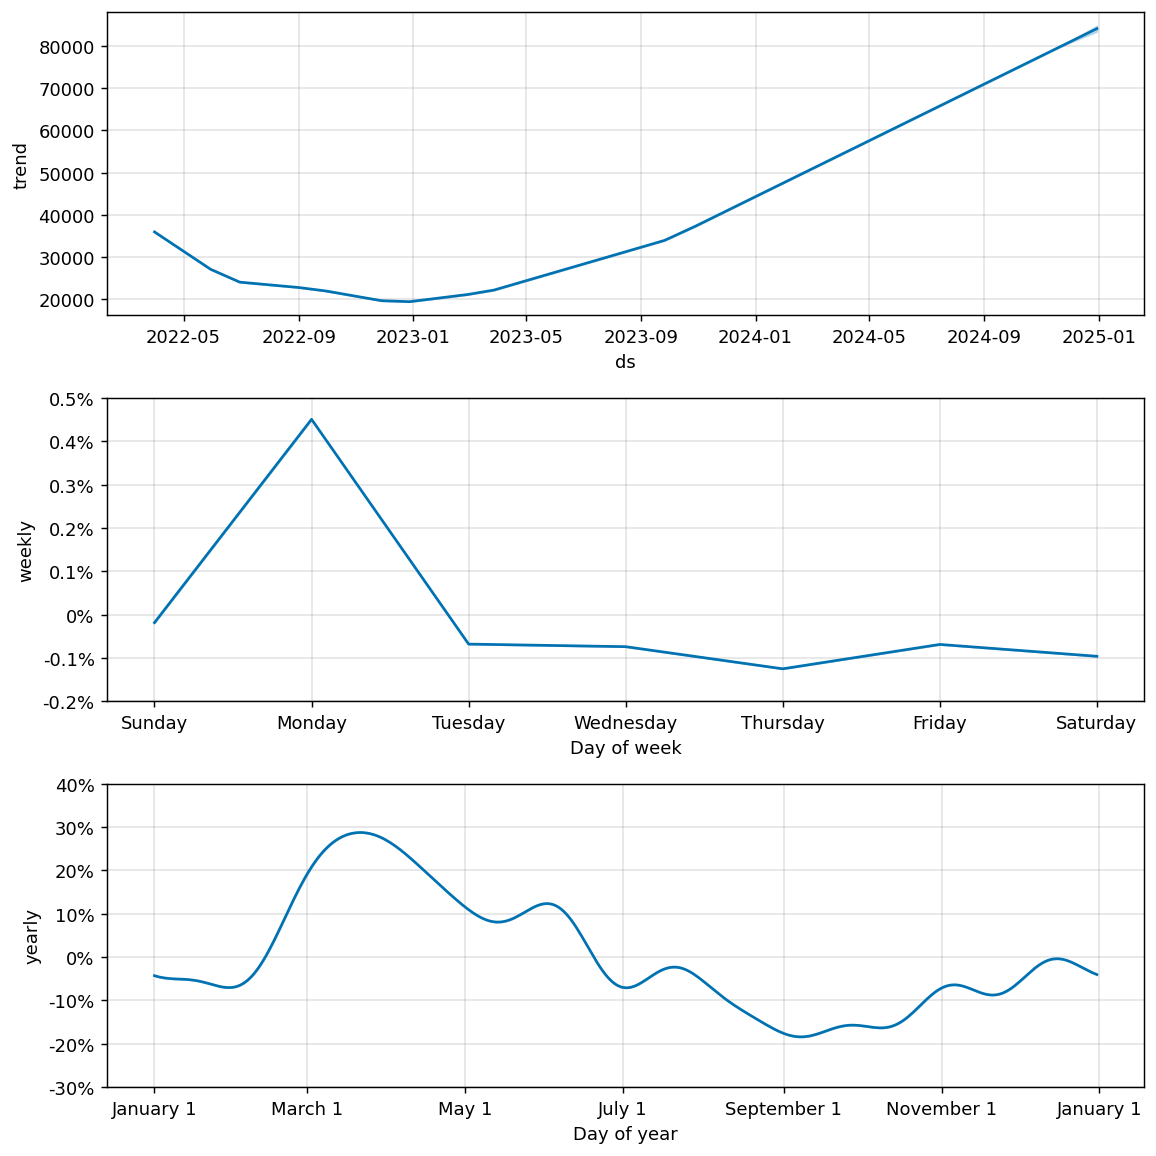

In [15]:
# Shows trend, weekly seasonality, yearly seasonality separately
fig2 = model_prophet.plot_components(forecast_prophet)
plt.tight_layout()
plt.savefig('../data/prophet_components.png', dpi=150)
plt.show()

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


In [17]:
close_prices = btc['close'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(close_prices)

print(f"Original range: ${close_prices.min():,.0f} → ${close_prices.max():,.0f}")
print(f"Scaled range:   {scaled.min():.3f} → {scaled.max():.3f}")

Original range: $15,787 → $106,141
Scaled range:   0.000 → 1.000


In [18]:
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])   # 60 days of input
        y.append(data[i, 0])             # next day target
    return np.array(X), np.array(y)

WINDOW = 60  # look-back period

X, y = create_sequences(scaled, WINDOW)

# Train/test split — last 60 rows = test
split = len(X) - 60
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# LSTM expects shape: (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (886, 60, 1) | X_test: (60, 60, 1)


In [19]:
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),

    LSTM(64, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)   # output: next day's price
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0129 - val_loss: 0.0020
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0015 - val_loss: 0.0022
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0016 - val_loss: 0.0038
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0010 - val_loss: 0.0013
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0011 - val_loss: 0.0018
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 9.6136e-04 - val_loss: 0.0012
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss:

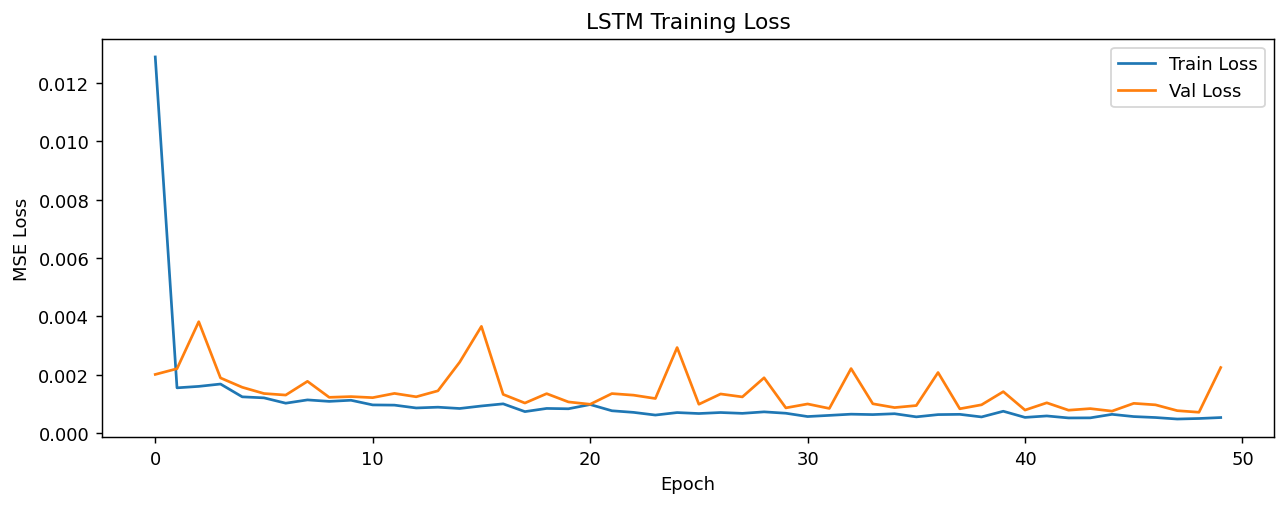

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,          # stop if no improvement for 10 epochs
    restore_best_weights=True
)

history = model_lstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot training loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Train Loss')
ax.plot(history.history['val_loss'], label='Val Loss')
ax.set_title('LSTM Training Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
predictions_scaled = model_lstm.predict(X_test)

# Convert back from 0-1 to actual USD values
predictions = scaler.inverse_transform(predictions_scaled)
actual_lstm  = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_l  = mean_absolute_error(actual_lstm, predictions)
rmse_l = np.sqrt(mean_squared_error(actual_lstm, predictions))
mape_l = np.mean(np.abs((actual_lstm - predictions) / actual_lstm)) * 100

print(f"\nLSTM Results:")
print(f"  MAE  : ${mae_l:,.2f}")
print(f"  RMSE : ${rmse_l:,.2f}")
print(f"  MAPE : {mape_l:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step

LSTM Results:
  MAE  : $6,137.16
  RMSE : $6,892.80
  MAPE : 6.50%


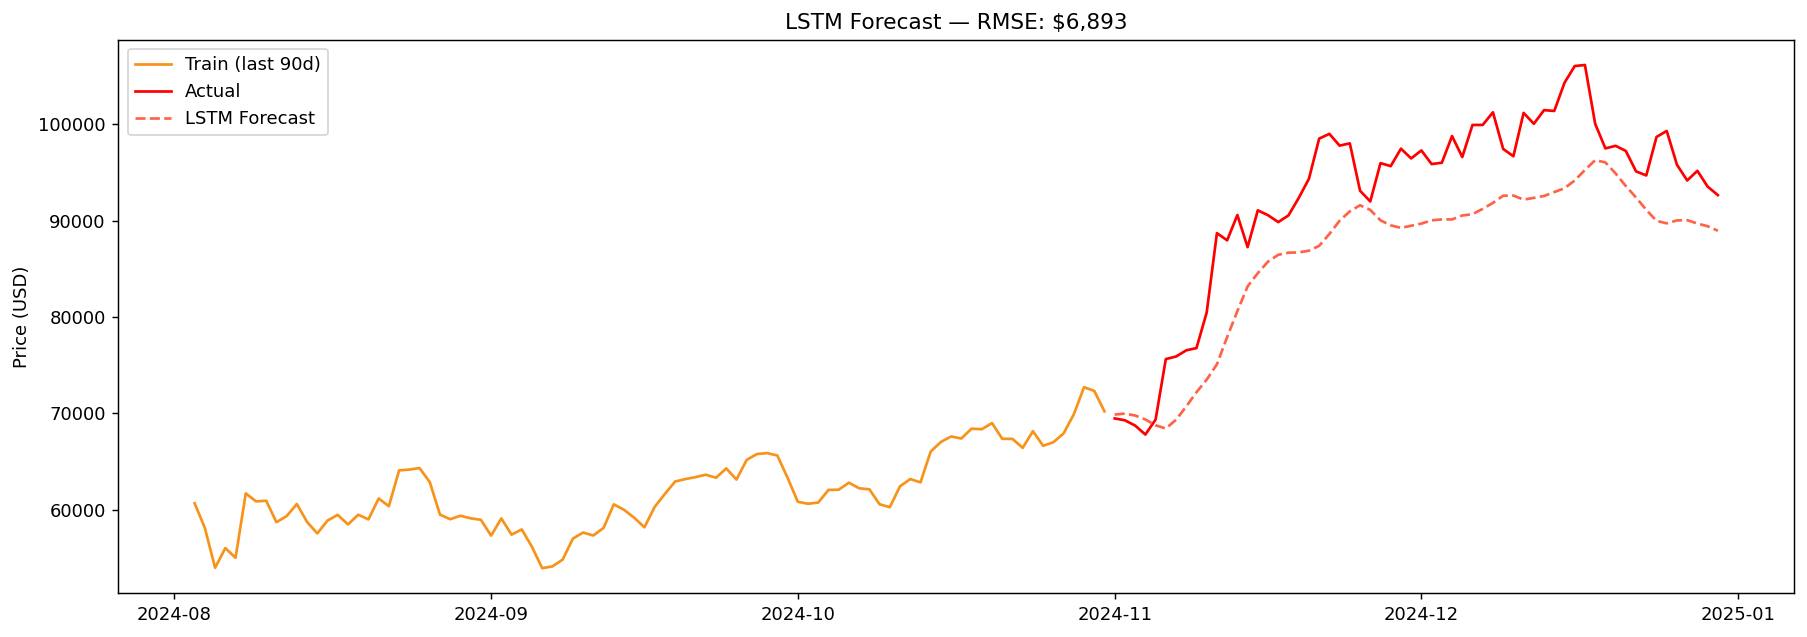

In [22]:
test_dates = btc.index[-60:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(btc.index[-150:-60], btc['close'].values[-150:-60],
        color='#F7931A', label='Train (last 90d)')
ax.plot(test_dates, actual_lstm,  color='red',   linewidth=1.5, label='Actual')
ax.plot(test_dates, predictions,  color='#FF6347', linewidth=1.5,
        linestyle='--', label='LSTM Forecast')
ax.set_title(f'LSTM Forecast — RMSE: ${rmse_l:,.0f}')
ax.legend(); ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.savefig('../data/lstm_forecast.png', dpi=150)
plt.show()

In [23]:
model_lstm.save('../models/lstm_btc.keras')
print("LSTM model saved ✓")

LSTM model saved ✓


In [24]:
results = pd.DataFrame({
    'Model':  ['ARIMA', 'Prophet', 'LSTM'],
    'MAE ($)':  [round(mae, 2),   round(mae_p, 2),  round(mae_l, 2)],
    'RMSE ($)': [round(rmse, 2),  round(rmse_p, 2), round(rmse_l, 2)],
    'MAPE (%)': [round(mape, 2),  round(mape_p, 2), round(mape_l, 2)]
})

results = results.sort_values('RMSE ($)')
print(results.to_string(index=False))
results.to_csv('../data/model_comparison.csv', index=False)
print("\nComparison saved ✓")

  Model  MAE ($)  RMSE ($)  MAPE (%)
   LSTM  6137.16   6892.80      6.50
Prophet 16044.31  17267.28     16.82
  ARIMA 22489.16  24295.43     23.41

Comparison saved ✓
